# TP2 — Classification multiclasses des caractères Tifinagh

MLP NumPy : **1024 → 64 → 32 → 33**


In [15]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [16]:
import cv2
print(cv2.__version__)

5.0.0


In [17]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report

data_dir = r"D:\master\tp2 dl\AMHCD_64\AMHCD_64"

print("Dataset exists:", os.path.exists(data_dir))
TARGET_SIZE = (32, 32)
LEARNING_RATE = 0.01
EPOCHS = 100
BATCH_SIZE = 32
RANDOM_STATE = 42

print("Dataset exists:", os.path.exists(data_dir))


Dataset exists: True
Dataset exists: True


## Fonctions d'activation


In [18]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


## Classe MLP multiclasses


In [19]:
class MultiClassNeuralNetwork:
    def __init__(self, layer_sizes, learning_rate=0.01):
        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.weights = []
        self.biases = []
        np.random.seed(RANDOM_STATE)
        for i in range(len(layer_sizes) - 1):
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01)
            self.biases.append(np.zeros((1, layer_sizes[i+1])))

    def forward(self, X):
        self.activations = [X]
        self.z_values = []
        for i in range(len(self.weights) - 1):
            z = self.activations[-1] @ self.weights[i] + self.biases[i]
            self.z_values.append(z)
            self.activations.append(relu(z))
        z = self.activations[-1] @ self.weights[-1] + self.biases[-1]
        self.z_values.append(z)
        output = softmax(z)
        self.activations.append(output)
        return output

    def compute_loss(self, y_true, y_pred):
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    def compute_accuracy(self, y_true, y_pred):
        return np.mean(np.argmax(y_pred, axis=1) == np.argmax(y_true, axis=1))

    def backward(self, X, y, outputs):
        m = X.shape[0]
        self.d_weights = [np.zeros_like(w) for w in self.weights]
        self.d_biases = [np.zeros_like(b) for b in self.biases]
        dZ = outputs - y
        self.d_weights[-1] = (self.activations[-2].T @ dZ) / m
        self.d_biases[-1] = np.sum(dZ, axis=0, keepdims=True) / m
        for i in range(len(self.weights) - 2, -1, -1):
            dZ = (dZ @ self.weights[i+1].T) * relu_derivative(self.z_values[i])
            self.d_weights[i] = (self.activations[i].T @ dZ) / m
            self.d_biases[i] = np.sum(dZ, axis=0, keepdims=True) / m
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * self.d_weights[i]
            self.biases[i] -= self.learning_rate * self.d_biases[i]

    def train(self, X, y, X_val, y_val, epochs, batch_size):
        train_losses, val_losses = [], []
        train_accuracies, val_accuracies = [], []
        for epoch in range(epochs):
            idx = np.random.permutation(X.shape[0])
            Xs, ys = X[idx], y[idx]
            epoch_loss, num_batches = 0.0, 0
            for i in range(0, X.shape[0], batch_size):
                Xb = Xs[i:i+batch_size]
                yb = ys[i:i+batch_size]
                outputs = self.forward(Xb)
                epoch_loss += self.compute_loss(yb, outputs)
                num_batches += 1
                self.backward(Xb, yb, outputs)
            train_loss = epoch_loss / num_batches
            train_pred = self.forward(X)
            val_pred = self.forward(X_val)
            train_acc = self.compute_accuracy(y, train_pred)
            val_loss = self.compute_loss(y_val, val_pred)
            val_acc = self.compute_accuracy(y_val, val_pred)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accuracies.append(train_acc)
            val_accuracies.append(val_acc)
            if epoch % 10 == 0 or epoch == epochs - 1:
                print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')
        return train_losses, val_losses, train_accuracies, val_accuracies

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)


## Prétraitement du dataset


In [20]:
def load_and_preprocess_image(image_path, target_size=TARGET_SIZE):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f'Failed to load image: {image_path}')
    img = cv2.resize(img, target_size)
    img = img.astype(np.float32) / 255.0
    return img.flatten()

image_paths, labels = [], []
for label_name in sorted(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label_name)
    if os.path.isdir(label_path):
        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)
            if os.path.isfile(img_path):
                image_paths.append(img_path)
                labels.append(label_name)

labels_df = pd.DataFrame({'image_path': image_paths, 'label': labels})
print('Images:', len(labels_df))
print('Classes:', labels_df['label'].nunique())


Images: 25740
Classes: 33


## Encodage et chargement des images


In [21]:
label_encoder = LabelEncoder()
labels_df['label_encoded'] = label_encoder.fit_transform(labels_df['label'])
num_classes = len(label_encoder.classes_)

X = np.array([load_and_preprocess_image(path) for path in labels_df['image_path']])
y = labels_df['label_encoded'].values

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (25740, 1024)
y shape: (25740,)


## Train / Validation / Test + One-Hot Encoding


In [22]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)

one_hot_encoder = OneHotEncoder(sparse_output=False)
y_train_one_hot = one_hot_encoder.fit_transform(y_train.reshape(-1, 1))
y_val_one_hot = one_hot_encoder.transform(y_val.reshape(-1, 1))
y_test_one_hot = one_hot_encoder.transform(y_test.reshape(-1, 1))

print('Train:', X_train.shape, y_train_one_hot.shape)
print('Validation:', X_val.shape, y_val_one_hot.shape)
print('Test:', X_test.shape, y_test_one_hot.shape)


Train: (15444, 1024) (15444, 33)
Validation: (5148, 1024) (5148, 33)
Test: (5148, 1024) (5148, 33)


## Création et entraînement du modèle


In [23]:
layer_sizes = [X_train.shape[1], 64, 32, num_classes]
nn = MultiClassNeuralNetwork(layer_sizes, learning_rate=LEARNING_RATE)

train_losses, val_losses, train_accuracies, val_accuracies = nn.train(
    X_train,
    y_train_one_hot,
    X_val,
    y_val_one_hot,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Epoch   0 | Train Loss: 3.4966 | Val Loss: 3.4965 | Train Acc: 0.0304 | Val Acc: 0.0305
Epoch  10 | Train Loss: 3.4964 | Val Loss: 3.4963 | Train Acc: 0.0826 | Val Acc: 0.0804
Epoch  20 | Train Loss: 3.4931 | Val Loss: 3.4918 | Train Acc: 0.0476 | Val Acc: 0.0478
Epoch  30 | Train Loss: 2.8035 | Val Loss: 2.7138 | Train Acc: 0.1200 | Val Acc: 0.1261
Epoch  40 | Train Loss: 2.1329 | Val Loss: 2.1962 | Train Acc: 0.2615 | Val Acc: 0.2570
Epoch  50 | Train Loss: 1.4999 | Val Loss: 1.3703 | Train Acc: 0.5607 | Val Acc: 0.5534
Epoch  60 | Train Loss: 0.9405 | Val Loss: 1.0057 | Train Acc: 0.6989 | Val Acc: 0.6948
Epoch  70 | Train Loss: 0.6788 | Val Loss: 0.9017 | Train Acc: 0.7191 | Val Acc: 0.7133
Epoch  80 | Train Loss: 0.5505 | Val Loss: 0.7784 | Train Acc: 0.7691 | Val Acc: 0.7648
Epoch  90 | Train Loss: 0.4537 | Val Loss: 0.7654 | Train Acc: 0.7777 | Val Acc: 0.7582
Epoch  99 | Train Loss: 0.4015 | Val Loss: 0.5602 | Train Acc: 0.8599 | Val Acc: 0.8361


## Évaluation


In [24]:
y_pred = nn.predict(X_test)
test_accuracy = np.mean(y_pred == y_test)
print('Test Accuracy:', f'{test_accuracy:.4f}')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Test Accuracy: 0.8364
              precision    recall  f1-score   support

          ya       0.97      0.99      0.98       156
         yab       0.91      0.97      0.94       156
        yach       0.93      0.89      0.91       156
         yad       0.97      0.90      0.93       156
        yadd       0.75      0.82      0.79       156
         yae       0.83      0.94      0.88       156
         yaf       0.97      0.92      0.94       156
         yag       0.89      0.82      0.85       156
        yagh       0.85      0.97      0.91       156
        yagw       0.99      0.62      0.76       156
         yah       0.92      0.79      0.85       156
        yahh       0.81      0.87      0.84       156
         yaj       0.95      0.84      0.89       156
         yak       0.83      0.82      0.83       156
        yakw       0.83      0.91      0.87       156
         yal       0.86      0.96      0.91       156
         yam       0.89      0.86      0.88       156
     

## Matrice de confusion


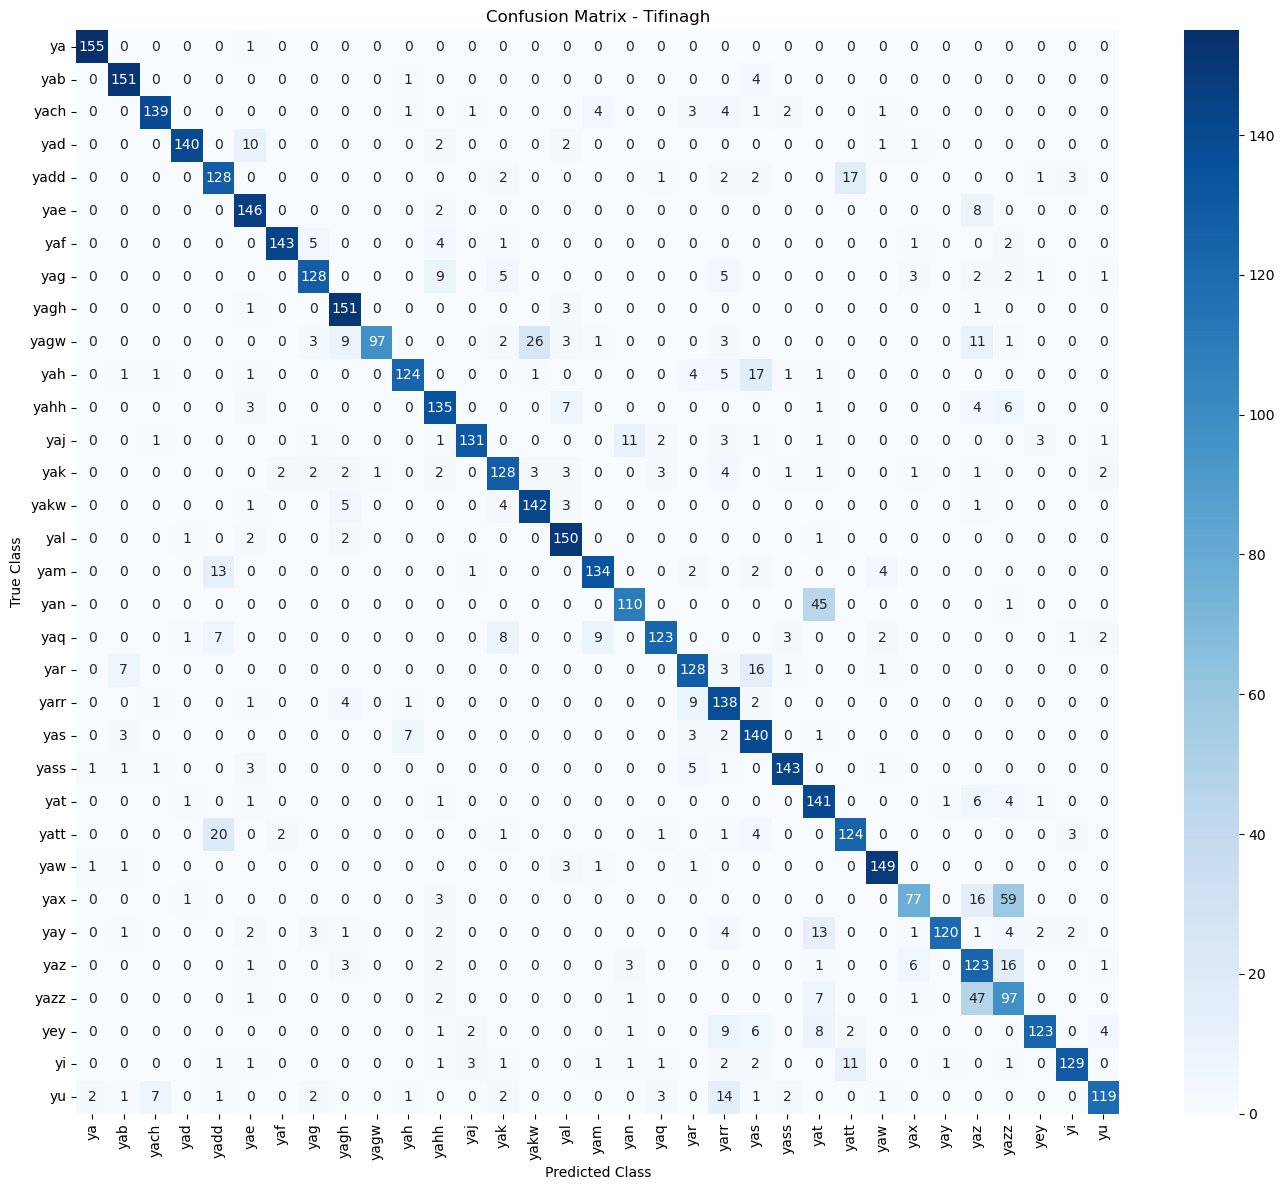

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Tifinagh')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()


## Courbes Loss / Accuracy


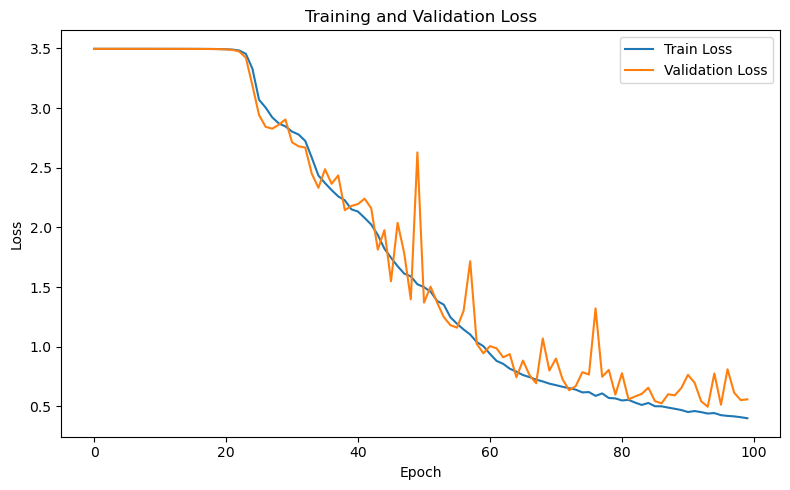

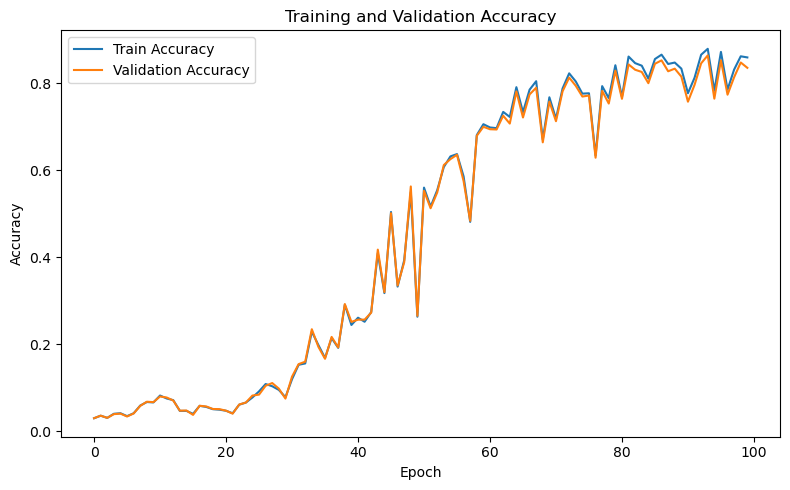

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_curve.png', dpi=300)
plt.show()
